# fastai — Data augmentation et entraînement d’un modèle performant
**Cybersup · Master 2 IA · Chrys NIONGOLO · Séance du vendredi 2 octobre 2026**

Suite de **fastai_model_to_production.ipynb** : hier, nous avons construit et exporté un classificateur d’ours ; aujourd’hui, nous apprenons à mesurer ce qui améliore son apprentissage.

**Repère dans le livre.** Le texte fourni correspond au **chapitre 7, « Training a State-of-the-Art Model »**, dans *Deep Learning for Coders with fastai and PyTorch* de Jeremy Howard et Sylvain Gugger (2020). Le [chapitre 17](https://github.com/fastai/fastbook/blob/master/17_foundations.ipynb) porte sur la construction d’un réseau à partir de ses fondations. [Notebook officiel du chapitre 7](https://github.com/fastai/fastbook/blob/master/07_sizing_and_tta.ipynb).

Ce support est un atelier original : explications en français, expériences guidées et protocole adapté au temps de classe. Le titre du chapitre décrit des techniques ; nos expériences courtes ne constituent pas un record de performance actuel.

**Ouverture :** importer ce fichier dans [Google Colab](https://colab.research.google.com/), puis choisir un runtime GPU. Les sorties sont volontairement vides ; l’entraînement et l’évaluation seront réalisés dans Colab.


## Objectifs et déroulé — 7 heures hors pauses

À la fin de la séance, vous saurez choisir des transformations qui préservent la classe, comparer deux entraînements sans changer le jeu de validation, combiner vitesse et résolution, expliquer MixUp et le lissage des étiquettes, puis évaluer le coût de la TTA.

| Séquence | Durée | Production attendue |
| --- | ---: | --- |
| Rappel du notebook d’ours et hypothèses | 20 min | Une hypothèse mesurable |
| Environnement, Imagenette et séparation des données | 35 min | Un manifeste de données |
| Visualiser les augmentations et la normalisation | 50 min | Une politique justifiée |
| Référence et comparaison contrôlée | 60 min | Deux expériences comparables |
| Redimensionnement progressif | 45 min | Un bilan précision / coût |
| MixUp et label smoothing | 70 min | Deux ablations et leur interprétation |
| TTA et sélection sur validation | 40 min | Un protocole d’inférence choisi |
| Évaluation finale et export | 45 min | Modèle, métadonnées et vérification de rechargement |
| Investigation en binôme et restitution | 55 min | Tableau d’expériences et conclusion |

**Prérequis :** comprendre un lot, une époque, la loss, le learning rate, un DataBlock et un Learner. Les rappels précèdent chaque notion nouvelle. Exécuter les cellules dans l’ordre ; aucun code à compléter ne bloque le parcours.


## 1. Préparer Colab

Importer ce fichier dans **Google Colab**, puis enregistrer une copie dans Drive. Pour la séance complète, choisir un runtime **Python 3 avec GPU**. Sans GPU CUDA, un parcours CPU réduit est sélectionné automatiquement. Le notebook utilise uniquement CUDA ou CPU ; sur un Mac, il choisit ici le CPU.

Une connexion Internet est nécessaire pour installer les dépendances et télécharger Imagenette. Aucun compte de recherche d’images, secret d’API, clonage du dépôt ou montage Drive n’est requis. Les fichiers créés dans le runtime restent temporaires.

La version fastai est fixée. PyTorch et torchvision déjà présents dans Colab sont conservés si compatibles ; leurs versions réelles sont enregistrées. Si Colab demande un redémarrage après installation, le faire puis relancer depuis le début.


In [1]:
import sys, subprocess, importlib.metadata as metadata

FASTAI_VERSION = "2.8.12"
try:
    installed_fastai = metadata.version("fastai")
except metadata.PackageNotFoundError:
    installed_fastai = None

if installed_fastai != FASTAI_VERSION:
    if "fastai" in sys.modules:
        raise RuntimeError("Redémarrer le noyau avant de changer de version fastai.")
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        f"fastai=={FASTAI_VERSION}",
    ])

from fastai.vision.all import *
from fastai.callback.mixup import MixUp
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay
from IPython.display import display
import gc, hashlib, json, os, platform, time, uuid
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torchvision

VERSIONS = {
    name: metadata.version(name)
    for name in ("fastai", "fastcore", "fasttransform", "torch", "torchvision",
                 "numpy", "pandas", "scikit-learn", "Pillow", "matplotlib",
                 "cloudpickle", "fastprogress")
}
VERSIONS["python"] = platform.python_version()
torch.set_num_threads(min(4, os.cpu_count() or 1))
display(pd.Series(VERSIONS, name="Version effective"))


,Version effective
fastai,2.8.12
fastcore,2.2.32
fasttransform,0.0.5
torch,2.11.0+cu128
torchvision,0.26.0+cu128
numpy,2.1.3
pandas,2.2.3
scikit-learn,1.6.1
Pillow,11.3.0
matplotlib,3.10.0


## 2. Choisir un budget avant de voir les résultats

**Même architecture, mêmes images, même graine, même batch size et mêmes deux cycles d’apprentissage** pour les cinq expériences. Seul le facteur annoncé change. Les tailles finales sont identiques au moment de l’évaluation.

| Profil | Train / validation / holdout par classe, au maximum | Résolutions | Époques par phase | Usage |
| --- | --- | --- | --- | --- |
| `cpu` | 20 / 10 / 10 | 64 → 96 | 1 + 1 | Comprendre le pipeline avec peu de calcul |
| `colab` | 250 / 60 / 100 | 128 → 224 | 3 + 2 | Atelier GPU |
| `long` | Tous les fichiers disponibles | 128 → 224 | 60 + 20 | Investigation prolongée, GPU requis |
| `smoke` | 3 / 2 / 2 | 32 → 48 | 1 + 1 | Vérifier le fonctionnement, sans conclusion scientifique |

`auto` choisit `colab` si CUDA est disponible, sinon `cpu`. Les durées dépendent du matériel ; le tableau de résultats chronométrera réellement chaque expérience. Le profil long lance **cinq entraînements de 80 époques** : il n’est pas nécessaire pour demain.

Le livre utilise XResNet-50 entraîné de zéro. Nous prenons **XResNet-18 sans poids préentraînés** pour accélérer les comparaisons. Le passage à `xresnet50` est une extension GPU ; il faut alors refaire toutes les références. Aucun poids ImageNet n’est téléchargé.


In [2]:
SEED = 42
PROFILE = os.environ.get("CYBERSUP_AUG_PROFILE", "auto")  # ou "cpu", "colab", "long"
ARCH = "xresnet18"  # extension GPU : "xresnet50"
BASE_LR = 3e-3
WEIGHT_DECAY = 1e-2
MIXUP_ALPHA = 0.4
SMOOTHING_EPS = 0.1
TTA_MIN_GAIN = 0.005  # au moins +0,5 point d'accuracy sur validation
TTA_MAX_TIME_RATIO = 6.0
RUN_LR_FINDER = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if PROFILE == "auto":
    PROFILE = "colab" if DEVICE.type == "cuda" else "cpu"

PROFILES = {
    "smoke": dict(train_cap=3, valid_cap=2, test_cap=2, small=32, large=48,
                  epochs=(1, 1), bs=8, tta_n=2, dataset="160"),
    "cpu": dict(train_cap=20, valid_cap=10, test_cap=10, small=64, large=96,
                epochs=(1, 1), bs=16, tta_n=2, dataset="160"),
    "colab": dict(train_cap=250, valid_cap=60, test_cap=100, small=128, large=224,
                  epochs=(3, 2), bs=32, tta_n=4, dataset="320"),
    "long": dict(train_cap=None, valid_cap=None, test_cap=None, small=128, large=224,
                 epochs=(60, 20), bs=32, tta_n=4, dataset="320"),
}
assert PROFILE in PROFILES, f"Profil inconnu : {PROFILE}"
assert ARCH in ("xresnet18", "xresnet50")
if (PROFILE == "long" or ARCH == "xresnet50") and DEVICE.type != "cuda":
    raise ValueError("Choisir un GPU CUDA pour ce budget, ou revenir à xresnet18/cpu.")

CFG = PROFILES[PROFILE].copy()
USE_FP16 = DEVICE.type == "cuda"
NUM_WORKERS = 0  # simple et portable ; augmenter ensuite uniquement si mesuré
PRESIZE = int(CFG["large"] * 1.5)
DATA_URL = URLs.IMAGENETTE_160 if CFG["dataset"] == "160" else URLs.IMAGENETTE_320
RUN_DIR = (Path("resultats") / f"augmentation_{uuid.uuid4().hex[:8]}").resolve()
RUN_DIR.mkdir(parents=True, exist_ok=False)
(RUN_DIR / "models").mkdir()
set_seed(SEED, reproducible=True)

ENVIRONMENT = {
    "profile": PROFILE, "device": str(DEVICE), "mixed_precision": USE_FP16,
    "hardware": torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else platform.machine(),
    "num_workers": NUM_WORKERS, "torch_threads": torch.get_num_threads(),
    "versions": VERSIONS,
}
print("Configuration :", CFG)
print("Calcul :", ENVIRONMENT["device"], ENVIRONMENT["hardware"], "| FP16 :", USE_FP16)
print("Résultats :", RUN_DIR)


Configuration : {'train_cap': 250, 'valid_cap': 60, 'test_cap': 100, 'small': 128, 'large': 224, 'epochs': (3, 2), 'bs': 32, 'tta_n': 4, 'dataset': '320'}
Calcul : cuda Tesla T4 | FP16 : True
Résultats : /content/resultats/augmentation_69d0812b


### Ce que nous optimisons

- **Temps d’itération :** un sous-ensemble stratifié, une architecture plus petite, puis des images plus grandes.
- **Mémoire GPU :** lots raisonnables et précision mixte uniquement sur CUDA.
- **Généralisation :** augmentations, MixUp et lissage des étiquettes.
- **Coût d’inférence :** une passe standard comparée à plusieurs vues TTA.

Une graine facilite la reproduction sans garantir des résultats identiques entre matériels, versions ou politiques aléatoires. Si la mémoire GPU manque, diminuer `bs` dans le profil, redémarrer, puis **refaire toutes les expériences avec cette valeur**. Ne pas masquer une erreur par un changement silencieux de configuration.


## 3. Imagenette : développer vite sans contaminer l’évaluation

Imagenette contient dix classes photographiques distinctes issues d’ImageNet. Nous téléchargeons une version déjà redimensionnée, puis construisons trois groupes :

1. **Train** : une partie du dossier officiel `train/`, pour mettre à jour les poids.
2. **Validation de développement** : une autre partie de `train/`, pour choisir les réglages.
3. **Holdout final du TP** : des fichiers du dossier officiel `val/`, gardés à l’écart jusqu’à la fin.

Le holdout est notre test pédagogique, **pas un test officiel ImageNet**. Le manifeste fixe les fichiers avant le premier entraînement. Aucun nouveau tirage lors du changement de résolution.

La séparation par fichier ne détecte pas les quasi-doublons. Avec des images d’ours collectées sur le Web, il faudrait aussi dédupliquer et séparer les prises proches ou les sources communes. Augmenter une image avant de la répartir entre train et validation créerait une fuite.

[Source du dataset et liste des classes](https://github.com/fastai/imagenette).


In [3]:
path = untar_data(DATA_URL)
assert (path / "train").is_dir() and (path / "val").is_dir()
source_train = sorted(get_image_files(path / "train"))
source_holdout = sorted(get_image_files(path / "val"))
CLASSES = sorted({p.parent.name for p in source_train})
assert len(CLASSES) == 10

train_pool, valid_pool = train_test_split(
    source_train, test_size=0.2, random_state=SEED,
    stratify=[p.parent.name for p in source_train],
)

def cap_per_class(files, cap, seed):
    rng = np.random.default_rng(seed)
    selected = []
    for label in CLASSES:
        group = sorted(p for p in files if p.parent.name == label)
        indices = rng.permutation(len(group))
        selected.extend(group[i] for i in indices[:cap])
    return sorted(selected)

train_files = cap_per_class(train_pool, CFG["train_cap"], SEED)
valid_files = cap_per_class(valid_pool, CFG["valid_cap"], SEED + 1)
holdout_files = cap_per_class(source_holdout, CFG["test_cap"], SEED + 2)
splits = {"train": train_files, "validation": valid_files, "holdout": holdout_files}
for name, files in splits.items():
    assert files and {p.parent.name for p in files} == set(CLASSES), name
assert not (set(train_files) & set(valid_files))
assert not (set(train_files + valid_files) & set(holdout_files))

manifest = pd.DataFrame([
    {"split": name, "file": p.relative_to(path).as_posix(), "label": p.parent.name}
    for name, files in splits.items() for p in files
])
manifest_csv = manifest.to_csv(index=False)
SPLIT_SHA256 = hashlib.sha256(manifest_csv.encode()).hexdigest()
(RUN_DIR / "split_manifest.csv").write_text(manifest_csv, encoding="utf-8")
DEV_FILES = train_files + valid_files
VALID_INDICES = list(range(len(train_files), len(DEV_FILES)))
display(pd.crosstab(manifest["label"], manifest["split"]))
print("Identifiant du split :", SPLIT_SHA256)


<div><progress max="341663724" value="341663744"></progress> 100.00% [341663744/341663724 00:06&lt;00:00]</div>

split,holdout,train,validation
label,,,
n01440764,100,250,60
n02102040,100,250,60
n02979186,100,250,60
n03000684,100,250,60
n03028079,100,250,60
n03394916,100,250,60
n03417042,100,250,60
n03425413,100,250,60
n03445777,100,250,60


Identifiant du split : ed80c0f6bc91ca0a2ff0d1f760d4ec0389241ea14594aec31eebf952ef3e29be


Les identifiants `n...` sont ceux des catégories ImageNet. Cette légende sert à lire les images ; les cibles du modèle restent les identifiants officiels.


In [4]:
CLASS_NAMES = {
    "n01440764": "tanche", "n02102040": "springer anglais",
    "n02979186": "lecteur de cassettes", "n03000684": "tronçonneuse",
    "n03028079": "église", "n03394916": "cor d'harmonie",
    "n03417042": "camion-poubelle", "n03425413": "pompe à essence",
    "n03445777": "balle de golf", "n03888257": "parachute",
}
display(pd.DataFrame({"classe": CLASSES, "nom": [CLASS_NAMES[c] for c in CLASSES]}))


,classe,nom
0,n01440764,tanche
1,n02102040,springer anglais
2,n02979186,lecteur de cassettes
3,n03000684,tronçonneuse
4,n03028079,église
5,n03394916,cor d'harmonie
6,n03417042,camion-poubelle
7,n03425413,pompe à essence
8,n03445777,balle de golf
9,n03888257,parachute


## 4. Voir une augmentation avant de l’utiliser

Une transformation doit représenter une variation plausible **sans changer l’étiquette**. Un miroir horizontal peut convenir ici ; pour reconnaître du texte ou certains signes, il peut changer le sens. Une rotation de 180° n’est pas systématiquement plausible. Un recadrage trop agressif peut supprimer l’objet.

Nous comparons `none` (pas de transformation aléatoire) et `mild` (miroir, petites rotations, lumière et recadrage modérés). Une politique `strong` sert uniquement à l’investigation.

**Presizing :** on conserve une image intermédiaire un peu plus grande avant les transformations du lot. Le padding initial préserve les proportions ; inspecter ses bordures et les recadrages. Les transformations aléatoires de fastai agissent sur **train** ; la validation utilise un traitement déterministe.

[Documentation des augmentations fastai](https://docs.fast.ai/vision.augment.html).

La petite classe `CenterPad` force un padding centré pour les deux splits : le `Resize/Pad` standard de fastai peut déplacer l’image aléatoirement pendant l’entraînement. Ce détail empêche une augmentation cachée dans A. L’export fastai inclut cette transformation.

**Deux chemins explicites.** `SplitBatchAugment` choisit le pipeline train ou validation avant d'appeler les transformations. Les rotations, miroirs et éclairages ne sont donc jamais appelés en validation ; celle-ci utilise un unique resize de tenseur, avec les mêmes paramètres pour toutes les politiques. La TTA choisit explicitement le chemin train pour ses vues augmentées.

Affecter seulement `t.split_idx = 0` ne suffit pas pour les transformations affines de fastai : `AffineCoordTfm.before_call` réécrit cet attribut. Une interpolation identité peut alors laisser des écarts numériques entre les politiques. Le `Resize` PIL reste dans `item_tfms` ; il ne remplace pas un resize de tenseur dans `batch_tfms`. [Source fastai 2.8.12](https://github.com/fastai/fastai/blob/2.8.12/fastai/vision/augment.py).

**Après mise à jour dans Colab :** remplacer puis réexécuter toute la cellule ci-dessous, y compris les deux classes et `make_dls`, puis la cellule de contrôle de la section 5. L'affichage doit indiquer `split-batch-v2`. Relancer seulement l'ancienne assertion conserverait les anciens objets en mémoire.


Prétraitement : split-batch-v2


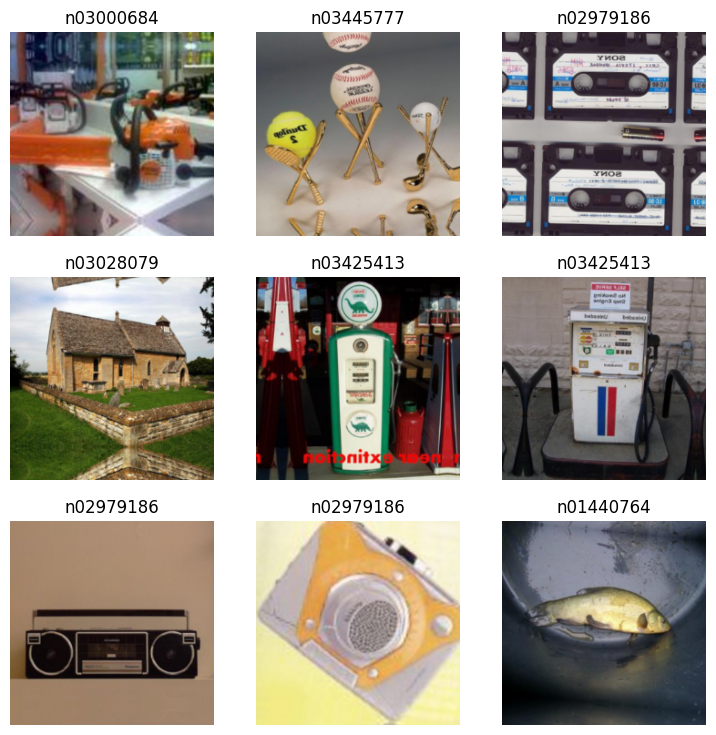

In [5]:
from fasttransform import Pipeline, Transform

PIPELINE_REVISION = "split-batch-v2"

class CenterPad(Resize):
    """Resize/Pad déterministe : aucun déplacement aléatoire dans la référence."""
    def before_call(self, b, split_idx):
        super().before_call(b, split_idx=1)

class SplitBatchAugment(Transform):
    """Choisir le pipeline AVANT d'appeler les transformations fastai."""
    order = 30  # après IntToFloatTensor, avant Normalize

    def __init__(self, train_tfms, valid_tfms):
        super().__init__()
        self.train_pipeline = Pipeline(train_tfms, split_idx=0)
        self.valid_pipeline = Pipeline(valid_tfms, split_idx=1)

    def __call__(self, batch, split_idx=None, **kwargs):
        # AffineCoordTfm réécrit son propre split_idx dans before_call.
        # La branche de validation ne doit donc jamais appeler ces augmentations.
        # Un split non précisé utilise aussi le chemin déterministe.
        pipeline = self.train_pipeline if split_idx == 0 else self.valid_pipeline
        return pipeline(batch)

def make_dls(size, policy="none", normalize=True):
    assert policy in ("none", "mild", "strong")
    train_tfms = []
    if policy != "none":
        strong = policy == "strong"
        train_tfms = aug_transforms(
            do_flip=True, flip_vert=False,
            max_rotate=25 if strong else 10,
            max_zoom=1.2 if strong else 1.1,
            max_lighting=0.35 if strong else 0.15,
            max_warp=0, min_scale=1.0,
        )

    min_scale = {"none": 1.0, "mild": 0.85, "strong": 0.5}[policy]
    train_tfms += [RandomResizedCropGPU(
        size, min_scale=min_scale, max_scale=1.0, ratio=(1, 1), valid_scale=1.0,
    )]
    # Un resize de TENSEUR identique pour toutes les politiques.
    # Avec split_idx=1 et valid_scale=1, l'image carrée entière est conservée.
    valid_tfms = [RandomResizedCropGPU(
        size, min_scale=1.0, max_scale=1.0, ratio=(1, 1), valid_scale=1.0,
    )]
    # Un seul adaptateur : DataBlock ne doit pas fusionner deux crops de même classe.
    transforms = [SplitBatchAugment(train_tfms, valid_tfms)]
    if normalize:
        transforms += [Normalize.from_stats(*imagenet_stats, cuda=DEVICE.type == "cuda")]

    block = DataBlock(
        blocks=(ImageBlock, CategoryBlock(vocab=CLASSES)),
        splitter=IndexSplitter(VALID_INDICES), get_y=parent_label,
        item_tfms=CenterPad(PRESIZE, method=ResizeMethod.Pad),
        batch_tfms=transforms,
    )
    return block.dataloaders(
        DEV_FILES, bs=CFG["bs"], num_workers=NUM_WORKERS,
        device=DEVICE, path=RUN_DIR,
    )

print("Prétraitement :", PIPELINE_REVISION)
preview_dls = make_dls(CFG["large"], "mild")
preview_dls.train.show_batch(max_n=9, nrows=3, figsize=(9, 9))
plt.show()


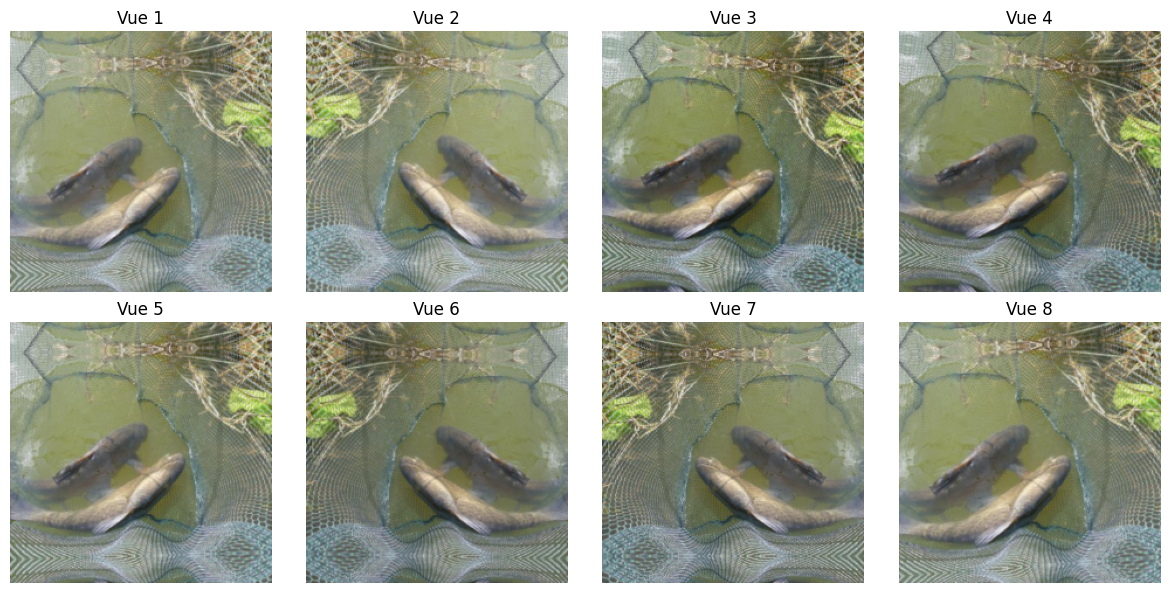

In [6]:
# Plusieurs versions d'une seule image de TRAIN, sans normalisation pour les voir.
sample_train = train_files[0]
padded = CenterPad(PRESIZE, method=ResizeMethod.Pad)(
    PILImage.create(sample_train), split_idx=1
)
raw = image2tensor(padded).float().div(255).unsqueeze(0)
views = TensorImage(raw.repeat(8, 1, 1, 1).to(DEVICE))
for transform in aug_transforms(size=CFG["large"], min_scale=0.85, max_warp=0,
                                max_rotate=10, max_lighting=0.15):
    views = transform(views, split_idx=0)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    show_image(views[i].cpu(), ax=ax, title=f"Vue {i + 1}")
plt.tight_layout()
plt.show()


**À discuter en binôme.** Quelle vue garde assez d’information pour identifier l’objet ? Quelle variation ressemble à une photo que l’application pourrait recevoir ? Proposez une transformation à interdire pour les ours et une à interdire pour des chiffres manuscrits.


## 5. Normaliser n’est pas augmenter

Une augmentation simule une variation des données. La normalisation transforme l’échelle numérique, canal par canal :

$$x'_c=\frac{x_c-\mu_c}{\sigma_c}.$$

Nous utilisons les statistiques ImageNet, car Imagenette en est issu. Elles ne sont pas estimées à partir du holdout. Le lot obtenu n’a pas nécessairement une moyenne exactement nulle : ce sont des statistiques de référence, pas celles de chaque mini-lot.

Avec un modèle préentraîné, il faut reprendre son prétraitement. Le \`vision_learner\` du notebook d’ours peut ajouter cette normalisation automatiquement ; ici, le \`Learner\` et le modèle initialisé de zéro exigent un choix explicite.

[Documentation du learner de vision](https://docs.fast.ai/vision.learner.html).


In [7]:
# Même lot avant/après : ne pas comparer deux tirages aléatoires différents.
raw_dls = make_dls(CFG["large"], "none", normalize=False)
x_raw, y_raw = raw_dls.valid.one_batch()
normalizer = Normalize.from_stats(*imagenet_stats, cuda=DEVICE.type == "cuda")
x_normalized = normalizer(x_raw.clone())
channel_stats = pd.DataFrame({
    "canal": ["R", "G", "B"],
    "moyenne_avant": x_raw.mean((0, 2, 3)).cpu().numpy(),
    "ecart_type_avant": x_raw.std((0, 2, 3)).cpu().numpy(),
    "moyenne_apres": x_normalized.mean((0, 2, 3)).cpu().numpy(),
    "ecart_type_apres": x_normalized.std((0, 2, 3)).cpu().numpy(),
})
display(channel_stats)

# Référence : mêmes FICHIERS, ordre, cibles et résolution dans tous les essais.
plain_dls = make_dls(CFG["large"], "none")
xp, yp = plain_dls.valid.one_batch()
expected_files = list(map(str, valid_files))
assert list(map(str, plain_dls.valid_ds.items)) == expected_files
expected_shape = (3, CFG["large"], CFG["large"])
assert tuple(xp.shape[1:]) == expected_shape
assert torch.isfinite(xp).all()

def check_validation(candidate_dls, reference_x, reference_y, context):
    assert list(map(str, candidate_dls.valid_ds.items)) == expected_files, (
        f"{context} : fichiers de validation différents ou ordre modifié."
    )
    x, y = candidate_dls.valid.one_batch()
    assert x.shape == reference_x.shape, (
        f"{context} : taille {tuple(x.shape)} au lieu de {tuple(reference_x.shape)}."
    )
    assert x.dtype == reference_x.dtype and x.device == reference_x.device
    assert torch.equal(y, reference_y), f"{context} : cibles différentes."
    assert torch.isfinite(x).all(), f"{context} : pixels non finis."
    delta_max = float((x - reference_x).abs().max())
    assert torch.allclose(x, reference_x, atol=1e-6, rtol=0), (
        f"{context} : delta_max={delta_max:.3e}, tolérance absolue=1e-6. "
        "Réexécuter la cellule complète CenterPad/SplitBatchAugment/make_dls "
        "de la section 4 avant ce contrôle ; ne pas augmenter la tolérance."
    )
    return delta_max

diagnostics = []
for policy in ("none", "mild", "strong"):
    candidate_dls = make_dls(CFG["large"], policy)
    first_delta = check_validation(candidate_dls, xp, yp, f"{policy}/premier passage")
    repeat_delta = check_validation(candidate_dls, xp, yp, f"{policy}/répétition")

    # Charger un lot train vérifie la taille et exerce l'état des augmentations.
    # Aucun modèle n'est créé ou entraîné par ces contrôles.
    xt, yt = candidate_dls.train.one_batch()
    assert tuple(xt.shape[1:]) == expected_shape, f"{policy} : taille train incorrecte."
    after_train_delta = check_validation(candidate_dls, xp, yp, f"{policy}/après train")

    # Même changement de split que Learner.tta : les vues augmentées restent possibles.
    with candidate_dls.valid_ds.set_split_idx(0):
        xtta, ytta = candidate_dls.valid.one_batch()
    assert xtta.shape == xp.shape and torch.equal(ytta, yp)
    assert torch.isfinite(xtta).all()
    after_tta_delta = check_validation(candidate_dls, xp, yp, f"{policy}/après vue TTA")

    diagnostics.append({
        "politique": policy, "delta_max": first_delta,
        "delta_repetition": repeat_delta, "delta_apres_train": after_train_delta,
        "delta_apres_tta": after_tta_delta,
    })

display(pd.DataFrame(diagnostics))
print(f"{PIPELINE_REVISION} : validation stable pour les trois politiques.")
del raw_dls, plain_dls, candidate_dls, x_raw, x_normalized, xp, yp, xt, yt, xtta, ytta
gc.collect()


,canal,moyenne_avant,ecart_type_avant,moyenne_apres,ecart_type_apres
0,R,0.434535,0.264790,-0.220370,1.156288
1,G,0.443902,0.255819,-0.054009,1.142047
2,B,0.397883,0.272441,-0.036077,1.210850


,politique,delta_max,delta_repetition,delta_apres_train,delta_apres_tta
0,none,0.0,0.0,0.0,0.0
1,mild,0.0,0.0,0.0,0.0
2,strong,0.0,0.0,0.0,0.0


split-batch-v2 : validation stable pour les trois politiques.


20252

## 6. Construire une comparaison contrôlée

Nous entraînons cinq modèles indépendants, avec la même initialisation aléatoire. Dans chaque expérience, les poids sont conservés entre les deux phases. Les cycles de learning rate sont les mêmes ; le second utilise un taux cinq fois plus petit.

| Expérience | Augmentation | Résolution phase 1 → 2 | Régularisation supplémentaire |
| --- | --- | --- | --- |
| A — référence | Aucune aléatoire | Grande → grande | Aucune |
| B — augmentation | Modérée | Grande → grande | Aucune |
| C — progressif | Modérée | Petite → grande | Aucune |
| D — MixUp | Modérée | Grande → grande | MixUp |
| E — lissage | Modérée | Grande → grande | Label smoothing |

Comparer **A/B**, **B/C**, **B/D**, **B/E**. Nous ne cumulons pas toutes les techniques dès le départ : il faut pouvoir attribuer un changement à une hypothèse.

Les époques sont fixées, sans arrêt anticipé. Le temps de calcul reste différent pour C, ce qui fait précisément l’objet de la mesure. La normalisation est présente dans **toutes** ces expériences.

Nous conservons les poids de chaque essai sur disque pour libérer la mémoire. Une loss de validation lissée n’est pas comparable à une cross-entropy classique : le tableau utilisera une **NLL commune calculée sur les probabilités et les vraies classes**, ainsi que l’accuracy et le score de Brier.


In [8]:
RESULTS, HISTORIES, EXPERIMENTS = {}, {}, {}

def synchronize():
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

def probability_metrics(preds, targets):
    p = preds.detach().float().cpu().as_subclass(torch.Tensor)
    y = targets.detach().long().cpu().as_subclass(torch.Tensor)
    assert p.shape == (len(y), len(CLASSES))
    assert torch.isfinite(p).all()
    assert torch.allclose(p.sum(1), torch.ones(len(y)), atol=1e-4)
    acc = (p.argmax(1) == y).float().mean().item()
    nll = -p[torch.arange(len(y)), y].clamp_min(1e-8).log().mean().item()
    one_hot = torch.nn.functional.one_hot(y, len(CLASSES)).float()
    brier = ((p - one_hot) ** 2).sum(1).mean().item()
    return {"accuracy": acc, "error_rate": 1 - acc, "nll": nll, "brier": brier}

def make_learner(dls, regularizer="none", fp16=USE_FP16):
    assert regularizer in ("none", "mixup", "smoothing")
    set_seed(SEED, reproducible=True)  # mêmes poids initiaux à chaque expérience
    factory = xresnet18 if ARCH == "xresnet18" else xresnet50
    model = factory(n_out=len(CLASSES), pretrained=False).to(DEVICE)
    loss = (LabelSmoothingCrossEntropyFlat(eps=SMOOTHING_EPS)
            if regularizer == "smoothing" else CrossEntropyLossFlat())
    callbacks = [MixUp(alpha=MIXUP_ALPHA)] if regularizer == "mixup" else []
    learner = Learner(
        dls, model, loss_func=loss, metrics=[accuracy, error_rate],
        cbs=callbacks, path=RUN_DIR, wd=WEIGHT_DECAY,
    )
    if fp16:
        learner = learner.to_fp16()
    return learner

def run_experiment(name, policy="mild", progressive=False, regularizer="none"):
    set_seed(SEED, reproducible=True)
    sizes = [CFG["small"] if progressive else CFG["large"], CFG["large"]]
    learner = make_learner(make_dls(sizes[0], policy), regularizer)
    history, seconds = [], 0.0
    if DEVICE.type == "cuda":
        torch.cuda.reset_peak_memory_stats()
    for phase, (size, epochs) in enumerate(zip(sizes, CFG["epochs"])):
        if phase:
            # Nouveau chargeur, mêmes fichiers, mêmes classes, mêmes poids.
            learner.dls = make_dls(size, policy)
        assert list(learner.dls.vocab) == CLASSES
        synchronize()
        started = time.perf_counter()
        learner.fit_one_cycle(
            epochs, lr_max=BASE_LR if phase == 0 else BASE_LR / 5,
            wd=WEIGHT_DECAY, reset_opt=True,
        )
        synchronize()
        seconds += time.perf_counter() - started
        for values in learner.recorder.values:
            history.append({
                "phase": phase + 1, "size": size,
                **dict(zip(learner.recorder.metric_names[1:-1], map(float, values))),
            })

    # Évaluation finale de chaque essai au même format, après les mêmes époques.
    preds, targets = learner.get_preds(dl=learner.dls.valid)
    metrics = probability_metrics(preds, targets)
    weights = RUN_DIR / "models" / f"{name}.pth"
    torch.save({k: v.detach().cpu() for k, v in learner.model.state_dict().items()}, weights)
    RESULTS[name] = {
        "name": name, "policy": policy, "progressive": progressive,
        "regularizer": regularizer, "sizes": sizes,
        "epochs": sum(CFG["epochs"]), "train_seconds": seconds,
        "peak_gpu_mib": torch.cuda.max_memory_allocated() / 2**20 if DEVICE.type == "cuda" else None,
        "split_sha256": SPLIT_SHA256, **metrics,
    }
    HISTORIES[name] = history
    EXPERIMENTS[name] = {"policy": policy, "regularizer": regularizer, "weights": weights}
    display(pd.DataFrame([RESULTS[name]]).round(4))
    del learner, preds, targets
    plt.close("all")
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    return RESULTS[name]


### Option : lire une courbe de learning rate

`lr_find` sonde le taux d’apprentissage ; ce n’est pas un entraînement à conserver. Le sondage est désactivé par défaut pour économiser du temps. Si vous l’activez, observez la courbe **avant** les comparaisons et choisissez ensuite un unique `BASE_LR` pour tous les essais. Ne modifier aucun réglage en regardant le holdout.

[Documentation de l’ordonnancement](https://docs.fast.ai/callback.schedule.html).


In [9]:
if RUN_LR_FINDER:
    probe = make_learner(make_dls(CFG["small"], "mild"))
    suggestion = probe.lr_find(num_it=40)
    print("Suggestion à interpréter :", suggestion)
    plt.show()
    del probe
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
else:
    print("Sondage désactivé ; BASE_LR commun =", BASE_LR)


Sondage désactivé ; BASE_LR commun = 0.003


## 7. A puis B : l’augmentation améliore-t-elle la validation ?

Écrire une hypothèse **avant** de lancer les deux cellules : variation attendue de l’accuracy, du temps et de l’écart train/validation. Les images transformées rendent souvent l’apprentissage plus difficile. Une loss train plus élevée ne suffit pas à conclure que le modèle est moins bon.

Les deux phases sont à grande résolution dans A et B. Seules les transformations aléatoires changent.


In [10]:
reference = run_experiment("A_reference", policy="none")

epoch,train_loss,valid_loss,accuracy,error_rate,time
0,1.965559,2.330528,0.276667,0.723333,00:25
1,1.684451,1.623491,0.466667,0.533333,00:24
2,1.415478,1.454695,0.553333,0.446667,00:24


epoch,train_loss,valid_loss,accuracy,error_rate,time
0,1.286785,1.447248,0.540000,0.460000,00:24
1,1.206697,1.341918,0.583333,0.416667,00:24


,name,policy,progressive,regularizer,sizes,epochs,train_seconds,peak_gpu_mib,split_sha256,accuracy,error_rate,nll,brier
0,A_reference,none,False,none,"[224, 224]",5,123.4414,816.9448,ed80c0f6bc91ca0a2ff0d1f760d4ec0389241ea14594aec31eebf952ef3e29be,0.5833,0.4167,1.3419,0.5681


In [11]:
augmented = run_experiment("B_augmentation", policy="mild")

epoch,train_loss,valid_loss,accuracy,error_rate,time
0,2.011438,2.571090,0.231667,0.768333,00:24
1,1.707183,2.100520,0.358333,0.641667,00:24
2,1.452676,1.473457,0.565000,0.435000,00:24


epoch,train_loss,valid_loss,accuracy,error_rate,time
0,1.309376,1.529658,0.545000,0.455000,00:24
1,1.219828,1.363025,0.606667,0.393333,00:24


,name,policy,progressive,regularizer,sizes,epochs,train_seconds,peak_gpu_mib,split_sha256,accuracy,error_rate,nll,brier
0,B_augmentation,mild,False,none,"[224, 224]",5,121.7044,876.1372,ed80c0f6bc91ca0a2ff0d1f760d4ec0389241ea14594aec31eebf952ef3e29be,0.6067,0.3933,1.363,0.5631


**Votre lecture :** quel est l’écart d’accuracy en points de pourcentage ? Quel est le coût supplémentaire ? Avec seulement quelques images et deux époques, quelle conclusion resterait prématurée ?


## 8. C : commencer petit, terminer plus grand

Le **progressive resizing** conserve les poids et change les DataLoaders : le modèle découvre d’abord des structures à faible coût, puis s’adapte aux détails. Il ne crée pas de nouveaux détails dans les fichiers d’origine.

C garde exactement le budget en époques et les deux cycles de B, mais remplace la résolution de la première phase. Nous gardons aussi le batch size constant pour isoler l’effet de la résolution. La validation intermédiaire à petite taille n’est pas utilisée pour classer les essais ; toutes les comparaisons finales sont faites à grande taille.

Ne pas appeler un nouveau constructeur de modèle entre les deux phases : cela effacerait l’apprentissage.


In [12]:
progressive = run_experiment("C_progressif", policy="mild", progressive=True)

epoch,train_loss,valid_loss,accuracy,error_rate,time
0,1.982304,2.354972,0.248333,0.751667,00:22
1,1.623507,1.609416,0.503333,0.496667,00:22
2,1.312950,1.301124,0.596667,0.403333,00:21


epoch,train_loss,valid_loss,accuracy,error_rate,time
0,1.227579,1.360412,0.618333,0.381667,00:24
1,1.128259,1.282661,0.648333,0.351667,00:24


,name,policy,progressive,regularizer,sizes,epochs,train_seconds,peak_gpu_mib,split_sha256,accuracy,error_rate,nll,brier
0,C_progressif,mild,True,none,"[128, 224]",5,115.3195,875.5435,ed80c0f6bc91ca0a2ff0d1f760d4ec0389241ea14594aec31eebf952ef3e29be,0.6483,0.3517,1.2827,0.5257


In [13]:
speed_ratio = RESULTS["B_augmentation"]["train_seconds"] / RESULTS["C_progressif"]["train_seconds"]
delta = 100 * (RESULTS["C_progressif"]["accuracy"] - RESULTS["B_augmentation"]["accuracy"])
print(f"Rapport temps B/C : {speed_ratio:.2f} ; écart d'accuracy C-B : {delta:+.2f} points.")


Rapport temps B/C : 1.06 ; écart d'accuracy C-B : +4.17 points.


## 9. D : MixUp, mélanger images et supervision

Pour deux images $(x_i,y_i)$ et $(x_j,y_j)$ :

$$\tilde{x}=\lambda x_i+(1-\lambda)x_j,\qquad
\tilde{y}=\lambda y_i+(1-\lambda)y_j,\qquad
\lambda\sim\mathrm{Beta}(\alpha,\alpha).$$

Les $y$ de cette formule sont des vecteurs one-hot. Une image contenant 70 % d’un exemple et 30 % d’un autre reçoit une supervision pondérée ; elle ne reçoit pas une classe inventée. Le callback calcule la combinaison des pertes sans exiger que l’on convertisse manuellement toutes les cibles.

MixUp peut freiner la mémorisation, mais rend la tâche plus difficile. Un essai court peut être moins bon. L’accuracy calculée sur les lots mélangés pendant l’entraînement ne remplace pas l’accuracy sur la validation intacte.

[Article original de Zhang et al.](https://arxiv.org/abs/1710.09412) et [callback fastai](https://docs.fast.ai/callback.mixup.html).


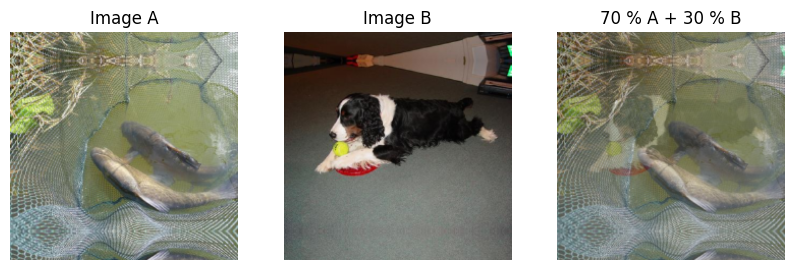

,Cible mélangée
n01440764,0.7
n02102040,0.3
n02979186,0.0
n03000684,0.0
n03028079,0.0
n03394916,0.0
n03417042,0.0
n03425413,0.0
n03445777,0.0
n03888257,0.0


In [14]:
# Illustration indépendante du callback : deux vraies images de classes différentes.
mix_dls = make_dls(CFG["large"], "none", normalize=False)
# Une sélection explicite garantit deux classes même si le premier lot est homogène.
other_file = next(p for p in train_files if p.parent.name != train_files[0].parent.name)
pair_dl = mix_dls.test_dl([train_files[0], other_file], with_labels=True, bs=2)
pair_x, pair_y = pair_dl.one_batch()
lam = 0.7
mixed_image = lam * pair_x[0] + (1 - lam) * pair_x[1]
soft_target = (
    lam * torch.nn.functional.one_hot(pair_y[0].long(), len(CLASSES))
    + (1 - lam) * torch.nn.functional.one_hot(pair_y[1].long(), len(CLASSES))
)
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for ax, im, title in zip(axes, [pair_x[0], pair_x[1], mixed_image],
                         ["Image A", "Image B", "70 % A + 30 % B"]):
    show_image(im.cpu(), ax=ax, title=title)
plt.show()
display(pd.Series(soft_target.cpu().numpy(), index=CLASSES, name="Cible mélangée"))
assert abs(float(soft_target.sum()) - 1.0) < 1e-6
del mix_dls, pair_dl, pair_x, pair_y


In [15]:
mixed = run_experiment("D_mixup", policy="mild", regularizer="mixup")


epoch,train_loss,valid_loss,accuracy,error_rate,time
0,2.173588,2.626120,0.210000,0.790000,00:24
1,1.955690,2.376107,0.301667,0.698333,00:24
2,1.776817,1.555400,0.523333,0.476667,00:24


epoch,train_loss,valid_loss,accuracy,error_rate,time
0,1.690222,1.652971,0.478333,0.521667,00:24
1,1.626086,1.464490,0.573333,0.426667,00:24


,name,policy,progressive,regularizer,sizes,epochs,train_seconds,peak_gpu_mib,split_sha256,accuracy,error_rate,nll,brier
0,D_mixup,mild,False,mixup,"[224, 224]",5,122.0954,895.6504,ed80c0f6bc91ca0a2ff0d1f760d4ec0389241ea14594aec31eebf952ef3e29be,0.5733,0.4267,1.4645,0.6159


## 10. E : label smoothing, adoucir la cible sans mélanger les images

Pour $K$ classes et un lissage $\varepsilon$ :

$$q_k=(1-\varepsilon)\,\mathbf{1}_{k=y}+\frac{\varepsilon}{K}.$$

Avec dix classes et $\varepsilon=0{,}1$, la bonne classe reçoit $0{,}91$, les neuf autres $0{,}01$. Le modèle n’est plus poussé vers une cible exactement égale à 1. Cela peut régulariser l’apprentissage ; cela ne corrige pas une mauvaise annotation et ne garantit pas des probabilités calibrées.

Pour distinguer son effet de MixUp, E utilise le même pipeline que B, avec uniquement une autre loss. Nous ne comparons pas directement les losses natives de D et E à celle de B.

[Article de Szegedy et al., section 7](https://arxiv.org/abs/1512.00567) ; [losses fastai](https://docs.fast.ai/losses.html).


In [16]:
target_index = 3
q = torch.full((len(CLASSES),), SMOOTHING_EPS / len(CLASSES))
q[target_index] += 1 - SMOOTHING_EPS
assert torch.allclose(q.sum(), torch.tensor(1.0))
display(pd.Series(q.numpy(), index=CLASSES, name="Cible lissée"))


,Cible lissée
n01440764,0.01
n02102040,0.01
n02979186,0.01
n03000684,0.91
n03028079,0.01
n03394916,0.01
n03417042,0.01
n03425413,0.01
n03445777,0.01
n03888257,0.01


In [17]:
smoothed = run_experiment("E_lissage", policy="mild", regularizer="smoothing")


epoch,train_loss,valid_loss,accuracy,error_rate,time
0,2.089823,2.436883,0.260000,0.740000,00:24
1,1.854386,1.965113,0.403333,0.596667,00:24
2,1.637790,1.646749,0.538333,0.461667,00:24


epoch,train_loss,valid_loss,accuracy,error_rate,time
0,1.525140,1.695724,0.565000,0.435000,00:24
1,1.451249,1.564695,0.600000,0.400000,00:24


,name,policy,progressive,regularizer,sizes,epochs,train_seconds,peak_gpu_mib,split_sha256,accuracy,error_rate,nll,brier
0,E_lissage,mild,False,smoothing,"[224, 224]",5,121.8574,876.7119,ed80c0f6bc91ca0a2ff0d1f760d4ec0389241ea14594aec31eebf952ef3e29be,0.6,0.4,1.3605,0.5795


## 11. Comparer les résultats réellement obtenus

L’accuracy est à maximiser ; la NLL et le Brier sont à minimiser. Le Brier ici est la moyenne de la **somme sur les classes** des erreurs quadratiques, pas leur moyenne par classe. Ces métriques sensibles aux probabilités ne sont pas, à elles seules, une preuve de calibration.

Le temps inclut les deux entraînements et leurs validations par époque, mais exclut le téléchargement, la construction des DataLoaders, l’évaluation supplémentaire et la sauvegarde. Les pics mémoire ne sont renseignés que sur CUDA.

Les comparaisons sont exploratoires : une seule graine et un petit sous-ensemble ne démontrent pas une supériorité générale. Aucun score du livre n’est recopié dans les résultats.


,name,accuracy_pct,gain_vs_A_pp,gain_vs_B_pp,nll,brier,train_seconds,relative_time_vs_B,peak_gpu_mib
0,A_reference,58.3333,0.0000,-2.3333,1.3419,0.5681,123.4414,1.0143,816.9448
1,B_augmentation,60.6667,2.3333,0.0000,1.3630,0.5631,121.7044,1.0000,876.1372
2,C_progressif,64.8333,6.5000,4.1667,1.2827,0.5257,115.3195,0.9475,875.5435
3,D_mixup,57.3333,-1.0000,-3.3333,1.4645,0.6159,122.0954,1.0032,895.6504
4,E_lissage,60.0000,1.6667,-0.6667,1.3605,0.5795,121.8574,1.0013,876.7119


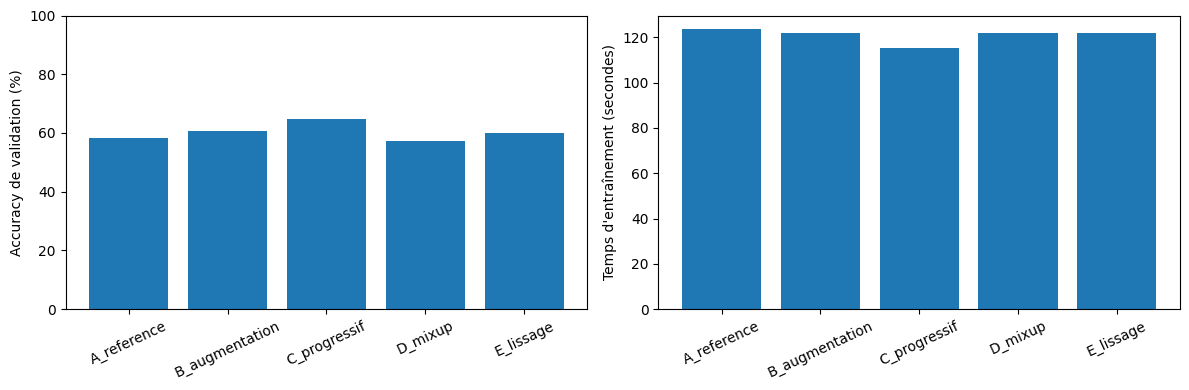

In [18]:
comparison = pd.DataFrame(RESULTS.values())
comparison["accuracy_pct"] = 100 * comparison["accuracy"]
comparison["gain_vs_A_pp"] = 100 * (
    comparison["accuracy"] - RESULTS["A_reference"]["accuracy"]
)
comparison["gain_vs_B_pp"] = 100 * (
    comparison["accuracy"] - RESULTS["B_augmentation"]["accuracy"]
)
comparison["relative_time_vs_B"] = (
    comparison["train_seconds"] / RESULTS["B_augmentation"]["train_seconds"]
)
display(comparison[[
    "name", "accuracy_pct", "gain_vs_A_pp", "gain_vs_B_pp", "nll", "brier",
    "train_seconds", "relative_time_vs_B", "peak_gpu_mib",
]].round(4))
comparison.to_csv(RUN_DIR / "comparison.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(comparison["name"], comparison["accuracy_pct"])
axes[0].set(ylabel="Accuracy de validation (%)", ylim=(0, 100))
axes[1].bar(comparison["name"], comparison["train_seconds"])
axes[1].set(ylabel="Temps d'entraînement (secondes)")
for ax in axes:
    ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()


**Compte rendu intermédiaire.** Remplir le tableau avec vos observations, y compris lorsqu’il n’y a pas de gain.

| Comparaison | Hypothèse | Gain observé | Coût | Conclusion limitée à ce protocole |
| --- | --- | --- | --- | --- |
| A / B | À rédiger | | | |
| B / C | À rédiger | | | |
| B / D | À rédiger | | | |
| B / E | À rédiger | | | |

**Arrêt avant le holdout :** les investigations de la section 15 doivent être décidées et exécutées maintenant. Pour changer un hyperparamètre global ou une graine, relancer le parcours dans un nouveau dossier de résultats. Ne pas revenir optimiser après lecture du test final.


## 12. TTA : plusieurs vues, un coût d’inférence à mesurer

Nous choisissons le modèle sur **l’accuracy de validation**, puis la NLL en cas d’égalité. La TTA utilise une politique modérée, y compris si la référence A gagne.

Les poids restent figés. fastai moyenne les probabilités de `n` vues augmentées et les combine à une vue déterministe. Avec `beta=0.25`, la vue déterministe pèse 25 % et la moyenne augmentée 75 %. Il y a donc **n + 1 passes**. Le gain n’est pas garanti.

Les deux mesures ci-dessous utilisent les mêmes poids, le même lot de validation et le float32. Un passage de chauffe précède le chronométrage ; le coût des transformations et des DataLoaders est inclus. Ce chronométrage local sur tout le jeu de validation n’est pas une mesure de latence d’une API en production.

La règle annoncée au début accepte la TTA seulement si son gain et son coût respectent les seuils. Le holdout n’intervient pas.

[Documentation officielle de TTA](https://docs.fast.ai/learner.html#tta).


In [19]:
best_name = min(RESULTS, key=lambda name: (-RESULTS[name]["accuracy"], RESULTS[name]["nll"], name))
champion = make_learner(make_dls(CFG["large"], "mild"), regularizer="none", fp16=False)
champion.model.load_state_dict(torch.load(
    EXPERIMENTS[best_name]["weights"], map_location=DEVICE, weights_only=True
))
champion.model.to(DEVICE).eval()

def timed_predictions(learner, dl, use_tta=False):
    synchronize()
    started = time.perf_counter()
    with learner.no_bar():
        if use_tta:
            set_seed(SEED, reproducible=True)
            preds, targets = learner.tta(dl=dl, n=CFG["tta_n"], beta=0.25)
        else:
            preds, targets = learner.get_preds(dl=dl)
    synchronize()
    return preds, targets, time.perf_counter() - started

with torch.inference_mode():
    champion.model(champion.dls.valid.one_batch()[0])
synchronize()
standard_p, standard_y, standard_seconds = timed_predictions(champion, champion.dls.valid)
tta_p, tta_y, tta_seconds = timed_predictions(champion, champion.dls.valid, use_tta=True)
assert torch.equal(standard_y, tta_y)
standard_metrics = probability_metrics(standard_p, standard_y)
tta_metrics = probability_metrics(tta_p, tta_y)
tta_gain = tta_metrics["accuracy"] - standard_metrics["accuracy"]
tta_time_ratio = tta_seconds / max(standard_seconds, 1e-9)
USE_TTA = bool(tta_gain >= TTA_MIN_GAIN and tta_time_ratio <= TTA_MAX_TIME_RATIO)
TTA_REPORT = {
    "standard": {**standard_metrics, "seconds": standard_seconds},
    "tta": {**tta_metrics, "seconds": tta_seconds},
    "n": CFG["tta_n"], "beta": 0.25, "gain_accuracy": tta_gain,
    "time_ratio": tta_time_ratio, "selected": USE_TTA,
    "min_gain": TTA_MIN_GAIN, "max_time_ratio": TTA_MAX_TIME_RATIO,
}
display(pd.DataFrame([TTA_REPORT["standard"], TTA_REPORT["tta"]],
                     index=["1 vue", f"TTA : {CFG['tta_n'] + 1} vues"]).round(4))
print("Modèle retenu :", best_name, "| TTA retenue :", USE_TTA)


,accuracy,error_rate,nll,brier,seconds
1 vue,0.6483,0.3517,1.2826,0.5257,4.2600
TTA : 5 vues,0.6467,0.3533,1.2189,0.5161,22.0014


Modèle retenu : C_progressif | TTA retenue : False


**Décision finale de développement.** Consigner pourquoi vous gardez ou rejetez la TTA. Un gain minime peut ne pas justifier plusieurs passes. Ne pas changer les seuils après avoir vu le test.

À partir de maintenant, architecture, poids, transformations et protocole d’inférence sont figés.


## 13. Évaluer le holdout une seule fois

Ce jeu n’a participé ni aux gradients, ni au choix du modèle, ni à la décision TTA. Nous rapportons le protocole retenu et sa référence à une vue, sans nouveau choix à partir de ces résultats.

Le petit holdout CPU a une incertitude élevée. Le même résultat ne démontrerait pas une robustesse aux photos hors domaine ou à de nouvelles conditions de prise de vue.


,accuracy,error_rate,nll,brier,seconds
Référence 1 vue,0.625,0.375,1.2275,0.5244,7.0781
Protocole retenu,0.625,0.375,1.2275,0.5244,7.0781


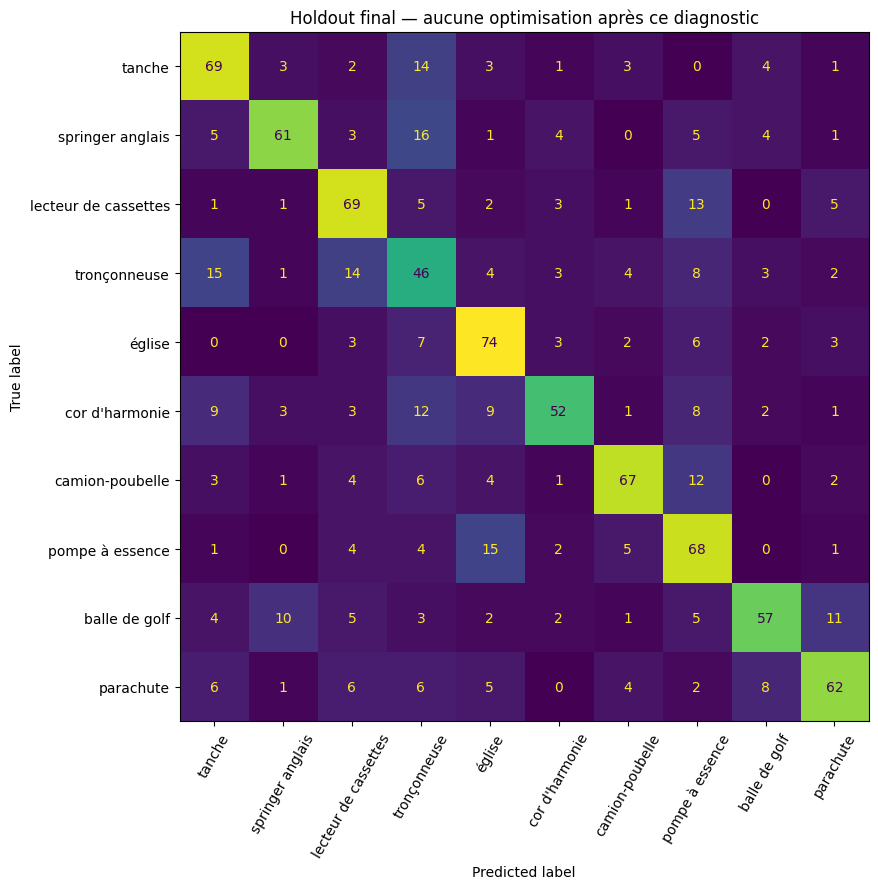

In [20]:
holdout_dl = champion.dls.test_dl(holdout_files, with_labels=True, bs=CFG["bs"],
                                num_workers=NUM_WORKERS)
holdout_p, holdout_y, holdout_seconds = timed_predictions(champion, holdout_dl)
holdout_standard_metrics = probability_metrics(holdout_p, holdout_y)
if USE_TTA:
    selected_p, selected_y, selected_seconds = timed_predictions(champion, holdout_dl, use_tta=True)
    assert torch.equal(selected_y, holdout_y)
else:
    selected_p, selected_y, selected_seconds = holdout_p, holdout_y, holdout_seconds

FINAL_REPORT = {
    "n_images": len(holdout_files), "best_model": best_name,
    "inference": "tta" if USE_TTA else "standard",
    "standard": {**holdout_standard_metrics, "seconds": holdout_seconds},
    "selected": {**probability_metrics(selected_p, selected_y), "seconds": selected_seconds},
}
display(pd.DataFrame([FINAL_REPORT["standard"], FINAL_REPORT["selected"]],
                     index=["Référence 1 vue", "Protocole retenu"]).round(4))

fig, ax = plt.subplots(figsize=(10, 9))
ConfusionMatrixDisplay.from_predictions(
    selected_y.cpu().numpy(), selected_p.argmax(1).cpu().numpy(),
    labels=list(range(len(CLASSES))), display_labels=[CLASS_NAMES[c] for c in CLASSES],
    xticks_rotation=60, ax=ax, colorbar=False,
)
ax.set_title("Holdout final — aucune optimisation après ce diagnostic")
plt.tight_layout()
plt.show()


**Diagnostic, pas nouvelle sélection.** Examiner une classe souvent confondue. La difficulté vient-elle de l’angle de vue, d’un objet petit dans l’image ou de l’arrière-plan ? Toute nouvelle idée devient une hypothèse pour une **prochaine** étude avec un autre test indépendant.


## 14. Revenir au notebook de production : exporter le pipeline complet

L’export conserve les poids, le vocabulaire et le prétraitement. Les métadonnées décrivent le split, les versions, les résolutions, la normalisation et les expériences.

**Attention au protocole :** `load_learner(...).predict(...)` réalise une prédiction standard ; il n’active pas automatiquement la TTA. La fonction ci-dessous applique explicitement le protocole sélectionné. Garder cette logique dans une future API si la TTA est retenue.

Le rechargement et la vérification CPU portent d’abord sur la prédiction standard, pour comparer deux résultats déterministes. Charger uniquement les exports pickle de confiance — ici, celui que nous venons de produire.

Une probabilité softmax de 80 % ne prouve pas la fiabilité d’une prédiction. Avant de réutiliser le seuil du notebook d’ours, il faudrait étudier la calibration, les erreurs et les données hors domaine.


In [21]:
# Inférence portable en float32 sur CPU.
champion.model.float().cpu()
champion.dls.to(torch.device("cpu"))
sample_for_reload = valid_files[0]
with champion.no_bar():
    before_export = champion.predict(sample_for_reload)[2].detach().cpu()
export_path = RUN_DIR / "model.pkl"
champion.export(export_path)
learn_inf = load_learner(export_path, cpu=True)
with learn_inf.no_bar():
    after_reload = learn_inf.predict(sample_for_reload)[2].detach().cpu()
assert torch.allclose(before_export, after_reload, atol=1e-6, rtol=1e-5)
print("Export puis rechargement CPU : prédictions standard identiques.")

def predict_with_protocol(image):
    """Reproduire explicitement la décision standard/TTA dans le notebook."""
    with learn_inf.no_bar():
        if USE_TTA:
            set_seed(SEED, reproducible=True)
            inference_dl = learn_inf.dls.test_dl([image], with_labels=False, bs=1, num_workers=0)
            probabilities, _ = learn_inf.tta(dl=inference_dl, n=CFG["tta_n"], beta=0.25)
            probabilities = probabilities[0].cpu()
        else:
            probabilities = learn_inf.predict(image)[2].cpu()
    index = int(probabilities.argmax())
    return {
        "label": str(learn_inf.dls.vocab[index]),
        "confidence": float(probabilities[index]),
        "protocol": "tta" if USE_TTA else "standard",
        "probabilities": dict(zip(map(str, learn_inf.dls.vocab), map(float, probabilities))),
    }

display(predict_with_protocol(sample_for_reload))


Export puis rechargement CPU : prédictions standard identiques.


/usr/local/lib/python3.13/dist-packages/fastai/learner.py:456: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


{'label': 'n01440764',
 'confidence': 0.8210204243659973,
 'protocol': 'standard',
 'probabilities': {'n01440764': 0.8210204243659973,
  'n02102040': 0.015061890706419945,
  'n02979186': 0.004592184908688068,
  'n03000684': 0.06475044786930084,
  'n03028079': 0.008764911442995071,
  'n03394916': 0.008397924713790417,
  'n03417042': 0.020399894565343857,
  'n03425413': 0.008606689982116222,
  'n03445777': 0.03300251066684723,
  'n03888257': 0.01540306955575943}}

In [22]:
MODEL_META = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "course": "Cybersup M2 — data augmentation", "book_chapter": 7,
    "architecture": ARCH, "pretrained": False, "seed": SEED,
    "dataset_url": DATA_URL, "split_manifest": "split_manifest.csv",
    "split_sha256": SPLIT_SHA256, "class_names": CLASS_NAMES, "vocab": CLASSES,
    "config": CFG, "presize": PRESIZE, "resize": "deterministic center padding",
    "preprocessing_revision": PIPELINE_REVISION,
    "normalization": {"mean": list(imagenet_stats[0]), "std": list(imagenet_stats[1])},
    "base_lr": BASE_LR, "weight_decay": WEIGHT_DECAY,
    "mixup_alpha": MIXUP_ALPHA, "smoothing_eps": SMOOTHING_EPS,
    "selected_experiment": best_name,
    "inference": {"use_tta": USE_TTA, "n": CFG["tta_n"], "beta": 0.25,
                  "augmentation_policy": "mild",
                  "export_predict_uses_tta_automatically": False},
    "environment": ENVIRONMENT,
    "export_sha256": hashlib.sha256(export_path.read_bytes()).hexdigest(),
}
REPORT = {
    "model": MODEL_META, "validation_experiments": RESULTS,
    "histories": HISTORIES, "tta_validation": TTA_REPORT,
    "holdout": FINAL_REPORT, "export_reload_check": True,
}
for filename, content in [("model_meta.json", MODEL_META), ("results.json", REPORT)]:
    (RUN_DIR / filename).write_text(
        json.dumps(content, indent=2, ensure_ascii=False, allow_nan=False) + "\n",
        encoding="utf-8",
    )
(RUN_DIR / "requirements-effective.txt").write_text(
    "\n".join(f"{name}=={version}" for name, version in VERSIONS.items() if name != "python") + "\n",
    encoding="utf-8",
)

# Archive fermée : uniquement le modèle final et les preuves de l'expérience.
import zipfile
artifact_names = [
    "model.pkl", "model_meta.json", "results.json", "split_manifest.csv",
    "comparison.csv", "requirements-effective.txt",
]
artifact_zip = RUN_DIR / "livrable_augmentation.zip"
with zipfile.ZipFile(artifact_zip, "w", compression=zipfile.ZIP_DEFLATED) as archive:
    for name in artifact_names:
        archive.write(RUN_DIR / name, arcname=name)
print("Archive à conserver :", artifact_zip)

DOWNLOAD_ARTIFACTS = False
if DOWNLOAD_ARTIFACTS:
    try:
        from google.colab import files
        files.download(str(artifact_zip))
    except ImportError:
        print("Hors Colab : récupérer le ZIP dans le dossier affiché.")


Archive à conserver : /content/resultats/augmentation_69d0812b/livrable_augmentation.zip


## 15. Investigation en binôme — à faire avant la section 12

Choisir **une seule** extension et annoncer le budget avant d’exécuter le holdout.

1. **Politique plus forte.** Lancer `run_experiment("F_forte", policy="strong")` après E. Comparer à B : plus d’augmentation peut-elle retirer l’information utile ?
2. **Hypothèse sur les ours.** Reprendre les données nettoyées d’hier, définir un split stable sans quasi-doublons, puis comparer une seule transformation. Ne pas mélanger le préentraînement et le changement d’augmentation dans la même comparaison.
3. **Entraînement long.** Sur GPU, utiliser le profil `long` dans une nouvelle exécution. Comparer B/D/E à budget égal ; une dégradation à deux époques prédit-elle celle à 80 époques ?
4. **Variabilité.** Refaire le protocole avec trois graines, en gardant le manifeste de données fixe et en séparant graine du split et graine du modèle. Rapporter moyenne et dispersion sur validation.
5. **Extension bibliographique.** Lire [CutMix (Yun et al., 2019)](https://arxiv.org/abs/1905.04899), puis expliquer ce qui change par rapport à MixUp avant de lancer un essai séparé.

Pour cumuler MixUp et lissage, commencer par une hypothèse de sous-régularisation et prévoir une nouvelle référence. Un cumul automatique peut rendre l’apprentissage trop difficile.

### Questions de consolidation

1. Pourquoi changer le split entre A et B invalide-t-il la comparaison ?
2. Pourquoi la validation doit-elle rester déterministe alors que l’entraînement est aléatoire ?
3. Quelle différence entre la normalisation des pixels et la BatchNorm du réseau ?
4. Qu’est-ce qui est conservé lors du progressive resizing ?
5. Avec cinq classes et `eps=0.1`, quelle est la cible lissée de la classe d’indice 1 ?
6. Pourquoi une dégradation de MixUp sur deux époques ne suffit-elle pas à le rejeter ?
7. Avec `n=4`, combien de passes fait la TTA de fastai ?
8. Pourquoi ne pas comparer directement les losses natives de B et E ?
9. Que perdrait une API qui charge le modèle retenu mais ignore la décision TTA ?
10. Quelle preuve supplémentaire faudrait-il avant d’annoncer une performance de production ?

### Travail à remettre

Enregistrer ce notebook avec les sorties et vos réponses, conserver le ZIP final, puis rédiger **dix lignes** : hypothèse, comparaison contrôlée, résultat, coût, limite et décision. Une expérience sans gain reste un résultat utile si son protocole et son interprétation sont corrects.


## Dépannage

| Symptôme | Action |
| --- | --- |
| Assertion sur les pixels de validation | Remplacer puis réexécuter la cellule complète de la section 4 et le contrôle de la section 5 ; vérifier `split-batch-v2` et les deltas affichés. Ne pas assouplir la tolérance |
| Installation interrompue ou import incohérent | Utiliser un runtime neuf, exécuter la préparation, puis vérifier les versions affichées |
| Téléchargement indisponible | Relancer quand le réseau est rétabli ; `untar_data` réutilise son cache |
| CPU trop lent | Choisir `cpu` ; réserver `smoke` au contrôle du pipeline, jamais à une conclusion |
| CUDA out of memory | Diminuer le batch size, redémarrer et refaire toutes les références |
| Accuracy très faible | Vérifier les images, les étiquettes et les dimensions ; le petit budget depuis zéro peut simplement être insuffisant |
| MixUp ou lissage moins bon | Vérifier le budget ; ne pas supposer un gain après quelques époques |
| Résultats différents entre machines | Comparer versions, manifeste, graine, périphérique, précision et budget |
| Fichier perdu après fermeture de Colab | Télécharger le ZIP et enregistrer une copie du notebook avant de quitter |

## Références vérifiées le 1er octobre 2026

- Howard & Gugger — [chapitre 7 : Training a State-of-the-Art Model](https://github.com/fastai/fastbook/blob/master/07_sizing_and_tta.ipynb) ; [chapitre 17 : A Neural Net from the Foundations](https://github.com/fastai/fastbook/blob/master/17_foundations.ipynb).
- fast.ai — [Imagenette](https://github.com/fastai/imagenette), [augmentations](https://docs.fast.ai/vision.augment.html), [vision learner et normalisation](https://docs.fast.ai/vision.learner.html).
- fastai — [MixUp / CutMix](https://docs.fast.ai/callback.mixup.html), [losses](https://docs.fast.ai/losses.html), [TTA](https://docs.fast.ai/learner.html#tta), [précision mixte](https://docs.fast.ai/callback.fp16.html).
- Zhang et al. — [mixup: Beyond Empirical Risk Minimization, 2017/2018](https://arxiv.org/abs/1710.09412).
- Szegedy et al. — [Rethinking the Inception Architecture for Computer Vision, 2015/2016](https://arxiv.org/abs/1512.00567).
- Yun et al. — [CutMix: Regularization Strategy to Train Strong Classifiers with Localizable Features, 2019](https://arxiv.org/abs/1905.04899).

Les exemples de ce notebook ne reproduisent pas les résultats du livre ni un benchmark actuel. Les conclusions doivent s’appuyer sur vos mesures et leur périmètre.
